In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
from IPython.display import display, HTML

In [2]:
# Set seaborn style for better visuals
sns.set(style="whitegrid")
%matplotlib inline

# Function to parse metric with mean and std
def parse_metric(metric_str):
    if not metric_str or pd.isna(metric_str):
        return None, None
    match = re.match(r'([\d.]+)\s*\(±([\d.]+)\)', metric_str)
    if match:
        return float(match.group(1)), float(match.group(2))
    return float(metric_str), None


# Load the data
df = pd.read_csv('Research Data - Summary.csv')

In [3]:
# Parse metrics into mean and std columns
df[['Accuracy_mean', 'Accuracy_std']] = df['Accuracy_Fixed_Testing'].apply(lambda x: pd.Series(parse_metric(x)))
df[['F1_mean', 'F1_std']] = df['F1_Fixed_Testing'].apply(lambda x: pd.Series(parse_metric(x)))
df[['Epochs_mean', 'Epochs_std']] = df['Epochs_Fixed_Testing'].apply(lambda x: pd.Series(parse_metric(x)))

In [4]:

df = df.rename(columns={
    'Base_Model_Class': 'Base_Model_Classes',
    'FT/Direct_Classes': 'FT_Direct_Classes',
    'FT/T_Instance_per_class': 'Instances_per_class'
})

# Convert 'Overlapping' to boolean for consistency
# df['Overlapping'] = df['Overlapping'].map({'Yes': True, 'No': False})

In [5]:
scrollable_table = f"""
<div style="height: 300px; overflow: auto;">
{df.to_html()}
</div>
"""
display(HTML(scrollable_table))

,Model,Accuracy,Accuracy_Fixed_Testing,F1,F1_Fixed_Testing,Epochs,Epochs_Fixed_Testing,Base_Model_Classes,FT_Direct_Classes,Instances_per_class,Model_Type,Overlapping,Accuracy_mean,Accuracy_std,F1_mean,F1_std,Epochs_mean,Epochs_std
0,240 Class ISL Base Model,0.6079,0.6079,NaN,NaN,NaN,NaN,240.0,NaN,NaN,BASE,No,0.6079,NaN,NaN,NaN,NaN,NaN
1,200 Class ISL Base Model,0.6247,0.6247,NaN,NaN,NaN,NaN,200.0,NaN,NaN,BASE,No,0.6247,NaN,NaN,NaN,NaN,NaN
2,160 Class ISL Base Model,0.6478,0.6478,NaN,NaN,NaN,NaN,160.0,NaN,NaN,BASE,No,0.6478,NaN,NaN,NaN,NaN,NaN
3,120 Class ISL Base Model,0.6173,0.6173,NaN,NaN,NaN,NaN,120.0,NaN,NaN,BASE,No,0.6173,NaN,NaN,NaN,NaN,NaN
4,80 Class ISL Base Model,0.6468,0.6468,NaN,NaN,NaN,NaN,80.0,NaN,NaN,BASE,No,0.6468,NaN,NaN,NaN,NaN,NaN
5,80 Class ISL Base Model (Overlapping class with SSL Dataset),0.6206,0.6206,NaN,NaN,NaN,NaN,80.0,NaN,NaN,BASE,Yes,0.6206,NaN,NaN,NaN,NaN,NaN
6,80 Class ISL Base Model (Movment Overlapping class with SSL Dataset),0.6905,0.6905,NaN,NaN,NaN,NaN,80.0,NaN,NaN,BASE,Movement,0.6905,NaN,NaN,NaN,NaN,NaN
7,240 Class ISL Base Model Finetuned with 64 Class SSL- 6 Instance per Class (5 runs avg),0.7746 (±0.0129),0.7616 (±0.0188),0.7663 (±0.0167),0.7595 (±0.0216),83.8000 (±9.9880),63.6000 (±15.5512),240.0,64.0,6.0,FINETUNED,No,0.7616,0.0188,0.7595,0.0216,63.6,15.5512
8,200 Class ISL Base Model Finetuned with 64 Class SSL- 6 Instance Per Class (5 runs avg),0.7272 (±0.0089),0.7670 (±0.0189),0.7213 (±0.0095),0.7595 (±0.0207),62.0000 (±7.6942),84.2000 (±18.8616),200.0,64.0,6.0,FINETUNED,No,0.7670,0.0189,0.7595,0.0207,84.2,18.8616
9,160 Class ISL Base Model Finetuned with 64 Class SSL- 6 Instance Per Class (5 runs avg),0.7629 (±0.0310),0.7522 (±0.0224),0.7552 (±0.0326),0.7498 (±0.0215),75.4000 (±10.8922),73.0000 (±10.2372),160.0,64.0,6.0,FINETUNED,No,0.7522,0.0224,0.7498,0.0215,73.0,10.2372


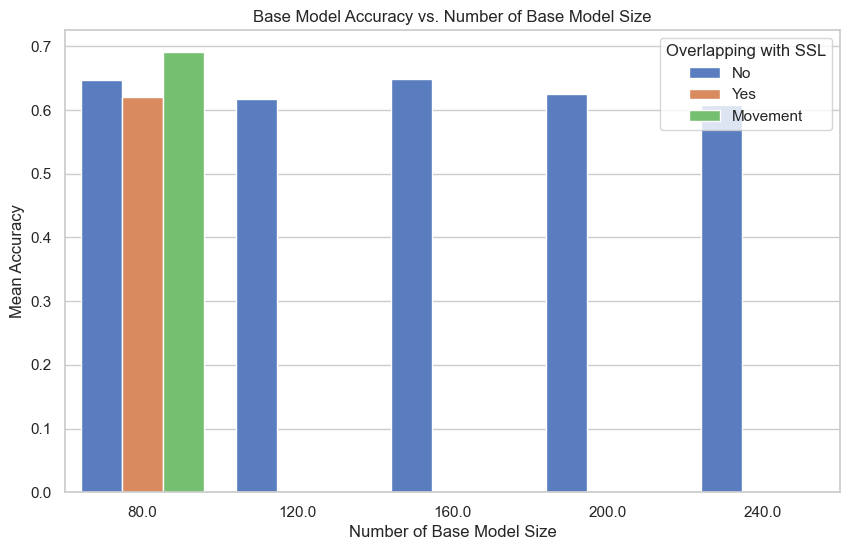

In [6]:
plt.figure(figsize=(10, 6))
base_df = df[df['Model_Type'] == 'BASE'].sort_values('Base_Model_Classes')
sns.barplot(x='Base_Model_Classes', y='Accuracy_mean', hue='Overlapping', palette='muted', data=base_df)
plt.title('Base Model Accuracy vs. Number of Base Model Size')
plt.xlabel('Number of Base Model Size')
plt.ylabel('Mean Accuracy')
plt.legend(title='Overlapping with SSL')
plt.show()

In [7]:
base_df

,Model,Accuracy,Accuracy_Fixed_Testing,F1,F1_Fixed_Testing,Epochs,Epochs_Fixed_Testing,Base_Model_Classes,FT_Direct_Classes,Instances_per_class,Model_Type,Overlapping,Accuracy_mean,Accuracy_std,F1_mean,F1_std,Epochs_mean,Epochs_std
4,80 Class ISL Base Model,0.6468,0.6468,NaN,NaN,NaN,NaN,80.0,NaN,NaN,BASE,No,0.6468,NaN,NaN,NaN,NaN,NaN
5,80 Class ISL Base Model (Overlapping class wit...,0.6206,0.6206,NaN,NaN,NaN,NaN,80.0,NaN,NaN,BASE,Yes,0.6206,NaN,NaN,NaN,NaN,NaN
6,80 Class ISL Base Model (Movment Overlapping c...,0.6905,0.6905,NaN,NaN,NaN,NaN,80.0,NaN,NaN,BASE,Movement,0.6905,NaN,NaN,NaN,NaN,NaN
3,120 Class ISL Base Model,0.6173,0.6173,NaN,NaN,NaN,NaN,120.0,NaN,NaN,BASE,No,0.6173,NaN,NaN,NaN,NaN,NaN
2,160 Class ISL Base Model,0.6478,0.6478,NaN,NaN,NaN,NaN,160.0,NaN,NaN,BASE,No,0.6478,NaN,NaN,NaN,NaN,NaN
1,200 Class ISL Base Model,0.6247,0.6247,NaN,NaN,NaN,NaN,200.0,NaN,NaN,BASE,No,0.6247,NaN,NaN,NaN,NaN,NaN
0,240 Class ISL Base Model,0.6079,0.6079,NaN,NaN,NaN,NaN,240.0,NaN,NaN,BASE,No,0.6079,NaN,NaN,NaN,NaN,NaN


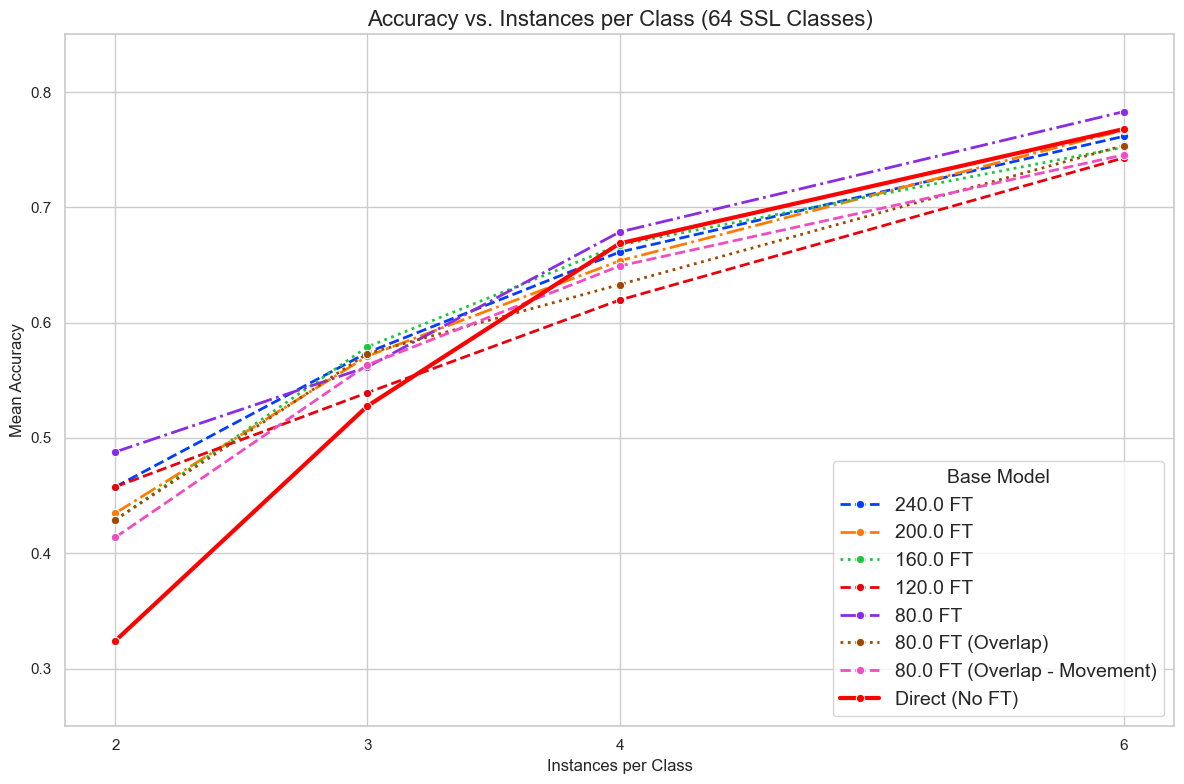

In [16]:

plt.figure(figsize=(12, 8))

# Filter data for 64 classes
ft_64 = df[(df['Model_Type'] == 'FINETUNED') & (df['FT_Direct_Classes'] == 64)]
direct_64 = df[(df['Model_Type'] == 'DIRECT') & (df['FT_Direct_Classes'] == 64)]
combined = pd.concat([ft_64, direct_64])

# Create Base_Model_Label with detailed Overlapping info
def get_overlap_label(row):
    if row['Model_Type'] == 'DIRECT':
        return 'Direct (No FT)'
    elif row['Overlapping'] == 'Yes':
        return f"{row['Base_Model_Classes']} FT (Overlap)"
    elif row['Overlapping'] == 'Movement':
        return f"{row['Base_Model_Classes']} FT (Overlap - Movement)"
    else:
        return f"{row['Base_Model_Classes']} FT"

combined['Base_Model_Label'] = combined.apply(get_overlap_label, axis=1)


# Filter for specific x-axis values (2, 3, 4, 6)
combined = combined[combined['Instances_per_class'].isin([2, 3, 4, 6])]

# Define custom styles and colors
unique_labels = combined['Base_Model_Label'].unique()
palette = sns.color_palette("bright", len(unique_labels))  # Distinct colors
styles = ['--', '-.', ':', '--', '-.', ':', '-']  # Line styles for Fine-tuned + solid for Direct
colors = {label: palette[i] for i, label in enumerate(unique_labels)}
colors['Direct (No FT)'] = '#FF0000'  # Red for Direct model

# Plot with custom styles
for label in unique_labels:
    subset = combined[combined['Base_Model_Label'] == label]
    if label == 'Direct (No FT)':
        # Highlight Direct with solid, bold line
        sns.lineplot(x='Instances_per_class', y='Accuracy_mean', data=subset,
                     label=label, color=colors[label], linestyle='-', linewidth=3, marker='o')
    else:
        # Fine-tuned models with dashed/dotted lines
        style_idx = list(unique_labels).index(label) % (len(styles) - 1)  # Avoid solid line
        sns.lineplot(x='Instances_per_class', y='Accuracy_mean', data=subset,
                     label=label, color=colors[label], linestyle=styles[style_idx], linewidth=2, marker='o')

# Customize plot
plt.title('Accuracy vs. Instances per Class (64 SSL Classes)', fontsize=16)
plt.xlabel('Instances per Class', fontsize=12)
plt.ylabel('Mean Accuracy', fontsize=12)
plt.xticks([2, 3, 4, 6])  # Explicitly set x-axis ticks
plt.legend(title='Base Model', loc='lower right', title_fontsize=14, fontsize=14)
plt.ylim((0.25, 0.85))
plt.tight_layout()
plt.show()

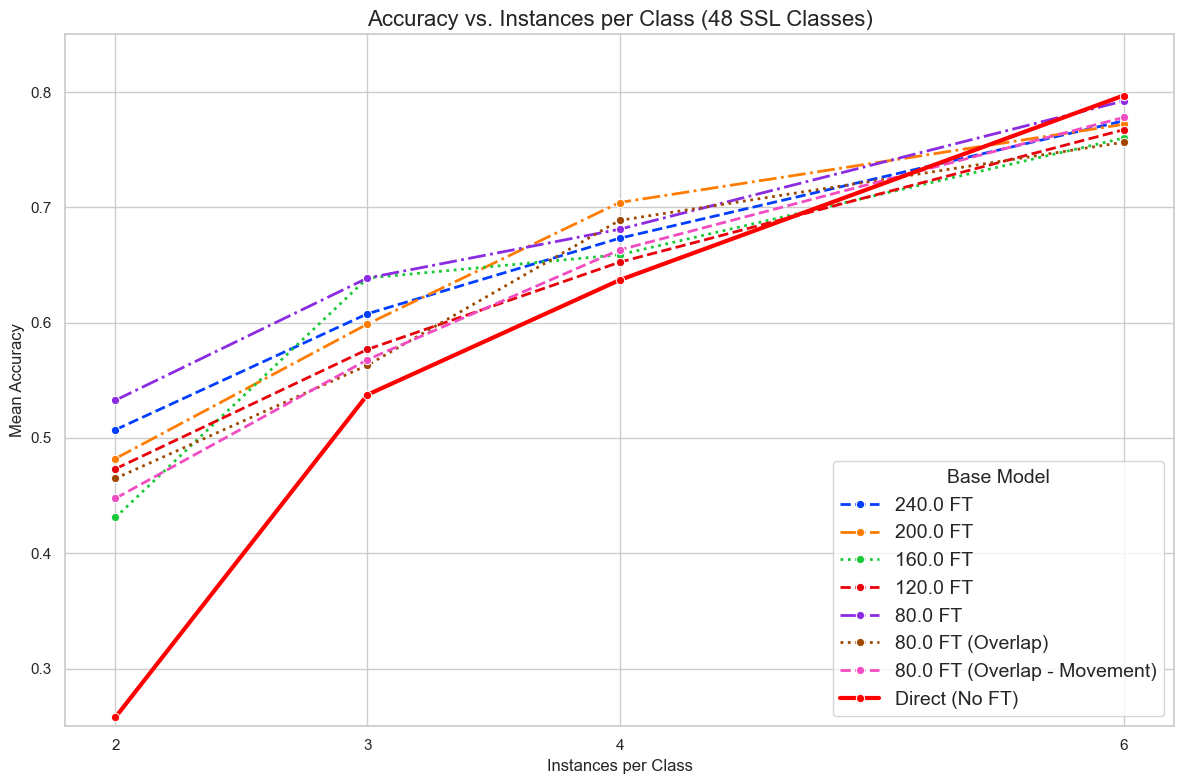

In [17]:
plt.figure(figsize=(12, 8))

# Filter data for 64 classes
ft_48 = df[(df['Model_Type'] == 'FINETUNED') & (df['FT_Direct_Classes'] == 48)]
direct_48 = df[(df['Model_Type'] == 'DIRECT') & (df['FT_Direct_Classes'] == 48)]
combined = pd.concat([ft_48, direct_48])

# Create Base_Model_Label with detailed Overlapping info
def get_overlap_label(row):
    if row['Model_Type'] == 'DIRECT':
        return 'Direct (No FT)'
    elif row['Overlapping'] == 'Yes':
        return f"{row['Base_Model_Classes']} FT (Overlap)"
    elif row['Overlapping'] == 'Movement':
        return f"{row['Base_Model_Classes']} FT (Overlap - Movement)"
    else:
        return f"{row['Base_Model_Classes']} FT"

combined['Base_Model_Label'] = combined.apply(get_overlap_label, axis=1)

# Filter for specific x-axis values (2, 3, 4, 6)
combined = combined[combined['Instances_per_class'].isin([2, 3, 4, 6])]

# Define custom styles and colors
unique_labels = combined['Base_Model_Label'].unique()
palette = sns.color_palette("bright", len(unique_labels))  # Distinct colors
styles = ['--', '-.', ':', '--', '-.', ':', '-']  # Line styles for Fine-tuned + solid for Direct
colors = {label: palette[i] for i, label in enumerate(unique_labels)}
colors['Direct (No FT)'] = '#FF0000'  # Red for Direct model

# Plot with custom styles
for label in unique_labels:
    subset = combined[combined['Base_Model_Label'] == label]
    if label == 'Direct (No FT)':
        # Highlight Direct with solid, bold line
        sns.lineplot(x='Instances_per_class', y='Accuracy_mean', data=subset,
                     label=label, color=colors[label], linestyle='-', linewidth=3, marker='o')
    else:
        # Fine-tuned models with dashed/dotted lines
        style_idx = list(unique_labels).index(label) % (len(styles) - 1)  # Avoid solid line
        sns.lineplot(x='Instances_per_class', y='Accuracy_mean', data=subset,
                     label=label, color=colors[label], linestyle=styles[style_idx], linewidth=2, marker='o')

# Customize plot
plt.title('Accuracy vs. Instances per Class (48 SSL Classes)', fontsize=16)
plt.xlabel('Instances per Class', fontsize=12)
plt.ylabel('Mean Accuracy', fontsize=12)
plt.xticks([2, 3, 4, 6])  # Explicitly set x-axis ticks
plt.legend(title='Base Model', loc='lower right', title_fontsize=14, fontsize=14)
plt.ylim((0.25, 0.85))
plt.tight_layout()
plt.show()

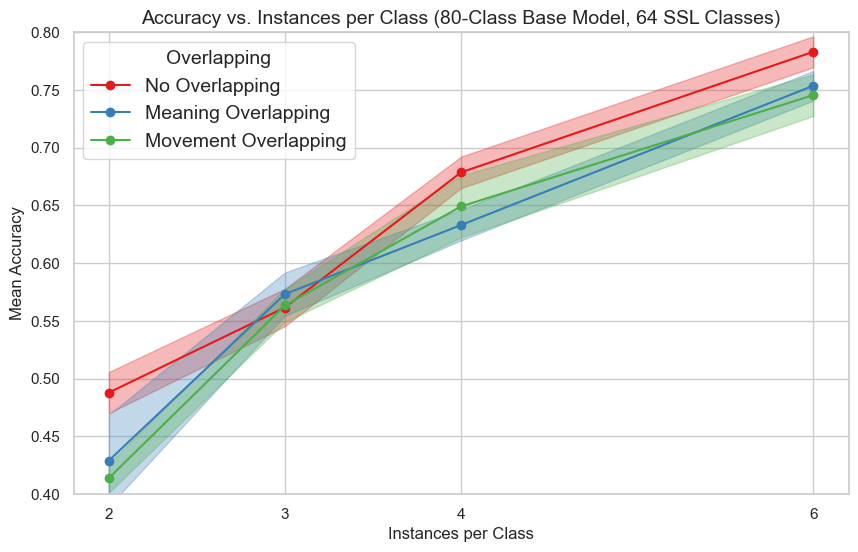

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

label_map = {
    'No': 'No Overlapping',
    'Yes': 'Meaning Overlapping',
    'Movement': 'Movement Overlapping'
}

plt.figure(figsize=(10, 6))

# Filter data
ft_80_64 = df[(df['Model_Type'] == 'FINETUNED') & (df['FT_Direct_Classes'] == 64) & (df['Base_Model_Classes'] == 80)]

# Define color palette
palette = sns.color_palette('Set1', n_colors=3)
overlap_categories = ft_80_64['Overlapping'].unique()

# Plot each line + shaded std
for i, overlap in enumerate(overlap_categories):
    sub_df = ft_80_64[ft_80_64['Overlapping'] == overlap].sort_values('Instances_per_class')

    plt.plot(sub_df['Instances_per_class'], sub_df['Accuracy_mean'],
            label=label_map.get(overlap, overlap),
            color=palette[i], marker='o')
    
    # Add shaded standard deviation
    plt.fill_between(sub_df['Instances_per_class'],
                     sub_df['Accuracy_mean'] - sub_df['Accuracy_std'],
                     sub_df['Accuracy_mean'] + sub_df['Accuracy_std'],
                     alpha=0.3, color=palette[i])

# Customize plot
plt.title('Accuracy vs. Instances per Class (80-Class Base Model, 64 SSL Classes)', fontsize=14)
plt.xlabel('Instances per Class', fontsize=12)
plt.ylabel('Mean Accuracy', fontsize=12)
plt.xticks([2, 3, 4, 6])
plt.ylim((0.4, 0.8))

# Add legend
plt.legend(title='Overlapping', title_fontsize=14, fontsize=14)

plt.show()




In [13]:
ft_80_64['Overlapping'].unique()

array(['No', 'Yes', 'Movement'], dtype=object)

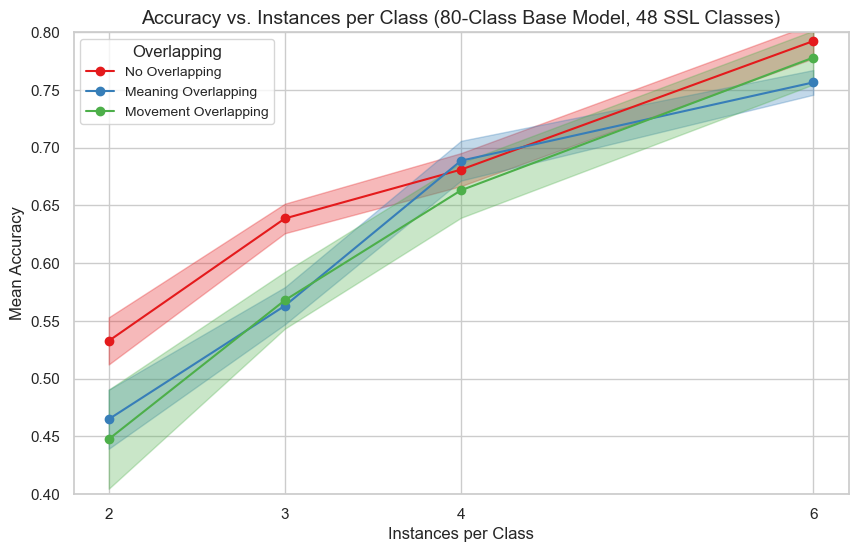

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

# Filter data
ft_80_64 = df[(df['Model_Type'] == 'FINETUNED') & (df['FT_Direct_Classes'] == 48) & (df['Base_Model_Classes'] == 80)]

# Define color palette
palette = sns.color_palette('Set1', n_colors=3)
overlap_categories = ft_80_64['Overlapping'].unique()

# Plot each line + shaded std
for i, overlap in enumerate(overlap_categories):
    sub_df = ft_80_64[ft_80_64['Overlapping'] == overlap].sort_values('Instances_per_class')
    plt.plot(sub_df['Instances_per_class'], sub_df['Accuracy_mean'],
            label=label_map.get(overlap, overlap),
            color=palette[i], marker='o')
    
    # Add shaded standard deviation
    plt.fill_between(sub_df['Instances_per_class'],
                     sub_df['Accuracy_mean'] - sub_df['Accuracy_std'],
                     sub_df['Accuracy_mean'] + sub_df['Accuracy_std'],
                     alpha=0.3, color=palette[i])

# Customize plot
plt.title('Accuracy vs. Instances per Class (80-Class Base Model, 48 SSL Classes)', fontsize=14)
plt.xlabel('Instances per Class', fontsize=12)
plt.ylabel('Mean Accuracy', fontsize=12)
plt.xticks([2, 3, 4, 6])
plt.ylim((0.4, 0.8))

# Add legend
plt.legend(title='Overlapping', title_fontsize=12, fontsize=10)

plt.show()


/tmp/ipykernel_180889/2976603717.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ft_64['Base_Model_Group'] = ft_64.apply(


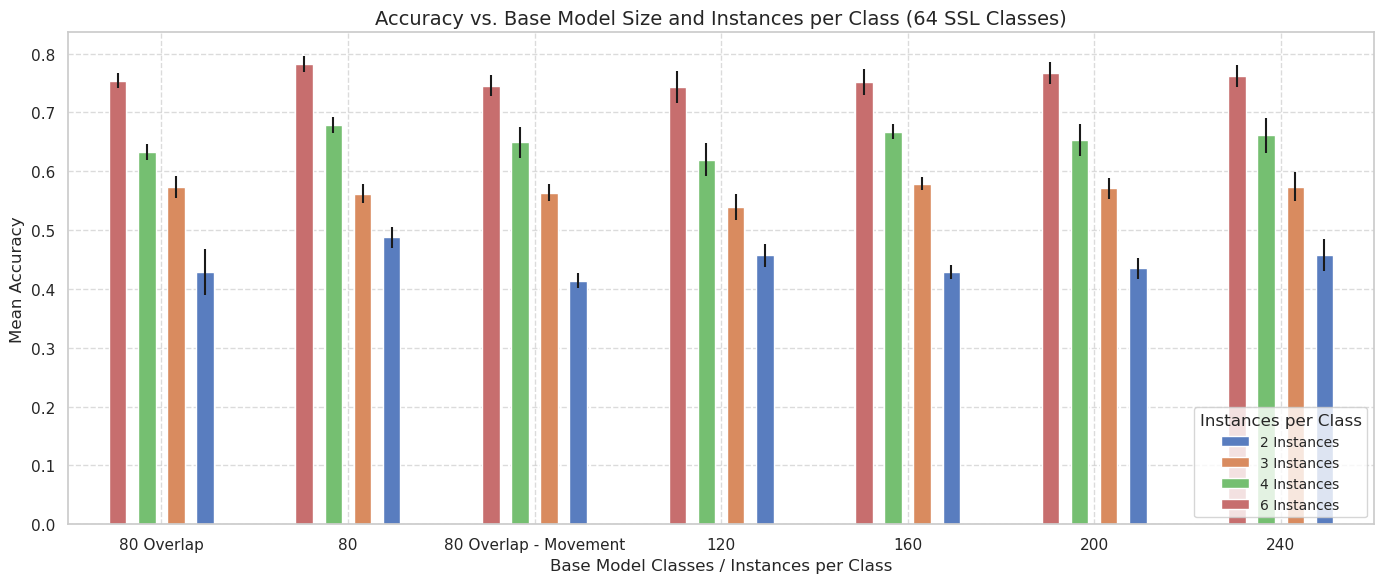

/tmp/ipykernel_180889/2976603717.py:86: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ft_48['Base_Model_Group'] = ft_48.apply(


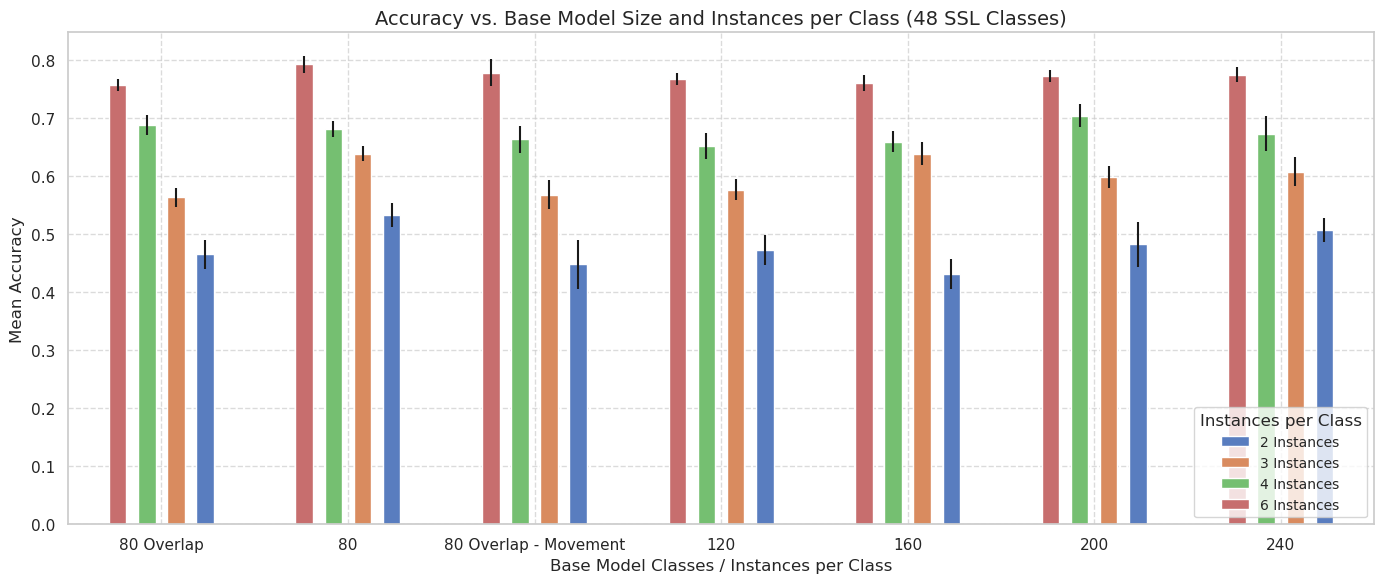

In [53]:
plt.figure(figsize=(14, 6))

# Filter data: Fine-tuned models with 64 SSL classes
ft_64 = df[(df['Model_Type'] == 'FINETUNED') & (df['FT_Direct_Classes'] == 64)]

# Mapping for overlap labels
overlap_label_map = {
    'Yes': ' Overlap',
    'Movement': ' Overlap - Movement',
    'No': ''
}

# Create new columns for grouping
ft_64['Base_Model_Group'] = ft_64.apply(
    lambda row: f"{int(row['Base_Model_Classes'])}{overlap_label_map.get(row['Overlapping'], '')}",
    axis=1
)


# Sort for correct plotting order
ft_64 = ft_64.sort_values(
    by=['Base_Model_Classes', 'Overlapping', 'Instances_per_class'],
    ascending=[True, False, False]
).reset_index(drop=True)

# Create plot index
ft_64['Plot_Index'] = range(len(ft_64))

# Plot
ax = sns.barplot(
    x='Plot_Index',
    y='Accuracy_mean',
    hue='Instances_per_class',
    palette='muted',
    data=ft_64,
    width=1.5,
    yerr=ft_64['Accuracy_std'],
)



# Fix label alignment: center each group
group_centers = []
group_labels = []
for group, group_df in ft_64.groupby('Base_Model_Group'):
    indices = group_df['Plot_Index'].tolist()
    center = sum(indices) / len(indices)
    group_centers.append(center)
    group_labels.append(group)

# Set only one label per group, centered
ax.set_xticks(group_centers)
ax.set_xticklabels(group_labels, ha='center')

# Customize plot
plt.title('Accuracy vs. Base Model Size and Instances per Class (64 SSL Classes)', fontsize=14)
plt.xlabel('Base Model Classes / Instances per Class', fontsize=12)
plt.ylabel('Mean Accuracy', fontsize=12)

# Fix legend labels
handles, _ = ax.get_legend_handles_labels()
plt.legend(handles=handles, labels=['2 Instances', '3 Instances', '4 Instances', '6 Instances'],
           title='Instances per Class', title_fontsize=12, fontsize=10, loc='lower right')

plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()



# ===============

plt.figure(figsize=(14, 6))

# Filter data: Fine-tuned models with 64 SSL classes
ft_48 = df[(df['Model_Type'] == 'FINETUNED') & (df['FT_Direct_Classes'] == 48)]

# Mapping for overlap labels
overlap_label_map = {
    'Yes': ' Overlap',
    'Movement': ' Overlap - Movement',
    'No': ''
}

# Create new columns for grouping
ft_48['Base_Model_Group'] = ft_48.apply(
    lambda row: f"{int(row['Base_Model_Classes'])}{overlap_label_map.get(row['Overlapping'], '')}",
    axis=1
)


# Sort for correct plotting order
ft_48 = ft_48.sort_values(
    by=['Base_Model_Classes', 'Overlapping', 'Instances_per_class'],
    ascending=[True, False, False]
).reset_index(drop=True)

# Create plot index
ft_48['Plot_Index'] = range(len(ft_48))

# Plot
ax = sns.barplot(
    x='Plot_Index',
    y='Accuracy_mean',
    hue='Instances_per_class',
    palette='muted',
    data=ft_48,
    width=1.5,
    yerr=ft_48['Accuracy_std'],
)



# Fix label alignment: center each group
group_centers = []
group_labels = []
for group, group_df in ft_48.groupby('Base_Model_Group'):
    indices = group_df['Plot_Index'].tolist()
    center = sum(indices) / len(indices)
    group_centers.append(center)
    group_labels.append(group)

# Set only one label per group, centered
ax.set_xticks(group_centers)
ax.set_xticklabels(group_labels, ha='center')

# Customize plot
plt.title('Accuracy vs. Base Model Size and Instances per Class (48 SSL Classes)', fontsize=14)
plt.xlabel('Base Model Classes / Instances per Class', fontsize=12)
plt.ylabel('Mean Accuracy', fontsize=12)

# Fix legend labels
handles, _ = ax.get_legend_handles_labels()
plt.legend(handles=handles, labels=['2 Instances', '3 Instances', '4 Instances', '6 Instances'],
           title='Instances per Class', title_fontsize=12, fontsize=10, loc='lower right')

plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


/tmp/ipykernel_180889/1994048984.py:6: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.lineplot(


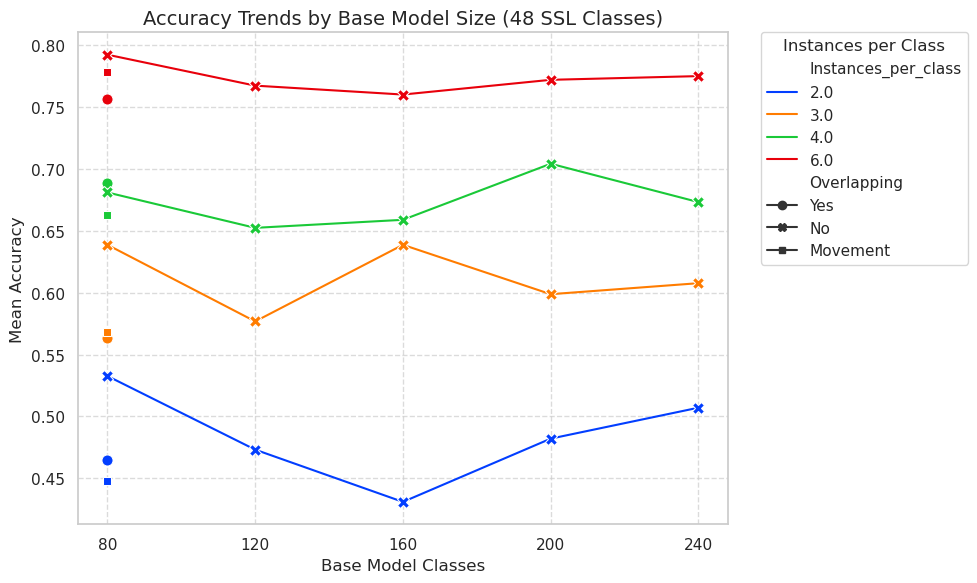

/tmp/ipykernel_180889/1994048984.py:35: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.lineplot(


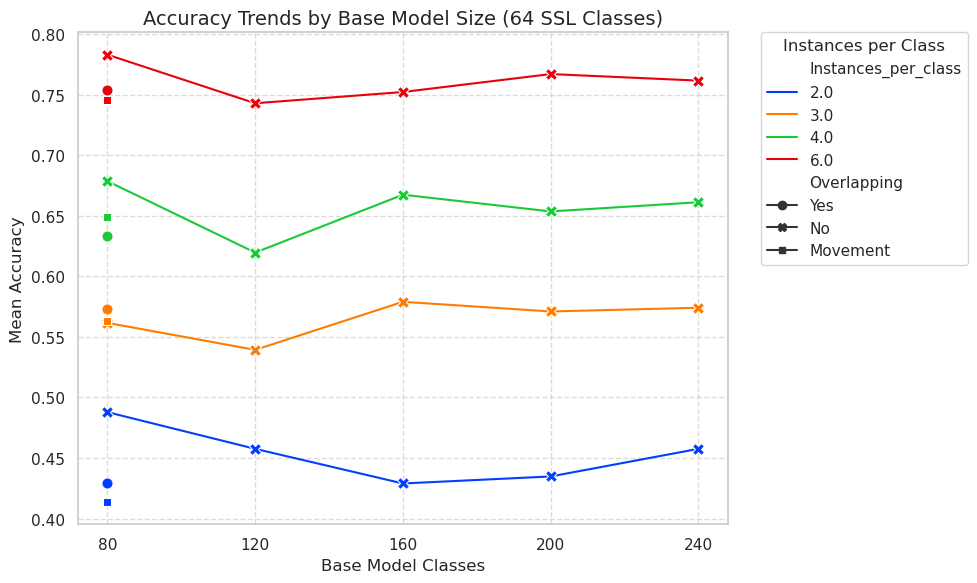

In [54]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plot for ft_48
plt.figure(figsize=(10, 6))
sns.lineplot(
    data=ft_48,
    x='Base_Model_Classes',
    y='Accuracy_mean',
    hue='Instances_per_class',
    style='Overlapping',
    markers=True,
    dashes=False,
    palette='bright',
    err_style='band',
    ci='sd',
    markersize=8  # Make markers bigger
)
plt.xticks([80, 120, 160, 200, 240])
plt.title('Accuracy Trends by Base Model Size (48 SSL Classes)', fontsize=14)
plt.xlabel('Base Model Classes', fontsize=12)
plt.ylabel('Mean Accuracy', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(
    title='Instances per Class',
    bbox_to_anchor=(1.05, 1),  # Move legend to the right
    loc='upper left',
    borderaxespad=0.
)
plt.tight_layout()
plt.show()

# Plot for ft_64
plt.figure(figsize=(10, 6))
sns.lineplot(
    data=ft_64,
    x='Base_Model_Classes',
    y='Accuracy_mean',
    hue='Instances_per_class',
    style='Overlapping',
    markers=True,
    dashes=False,
    palette='bright',
    err_style='band',
    ci='sd',
    markersize=8  # Make markers bigger
)
plt.xticks([80, 120, 160, 200, 240])
plt.title('Accuracy Trends by Base Model Size (64 SSL Classes)', fontsize=14)
plt.xlabel('Base Model Classes', fontsize=12)
plt.ylabel('Mean Accuracy', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(
    title='Instances per Class',
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    borderaxespad=0.
)
plt.tight_layout()
plt.show()
